<a href="https://colab.research.google.com/github/hyui02/miniproject1/blob/main/%EC%98%81%ED%99%94%EA%B4%80%EA%B0%9D_%EA%B3%84%EC%A0%88_%ED%8F%AC%EC%BB%A4%EC%8B%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0단계

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('/content/movies_train.csv')

!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_month'] = train['release_time'].dt.month
season_map = {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
              6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을'}
train['season'] = train['release_month'].map(season_map)
season_order = ['봄', '여름', '가을', '겨울']

print(train['season'].isna().sum())
print(train['season'].value_counts().loc[season_order])
print(train['release_month'].value_counts().sort_index())

0
season
봄     156
여름    133
가을    192
겨울    119
Name: count, dtype: int64
release_month
1     39
2     31
3     52
4     47
5     57
6     29
7     49
8     55
9     60
10    60
11    72
12    49
Name: count, dtype: int64


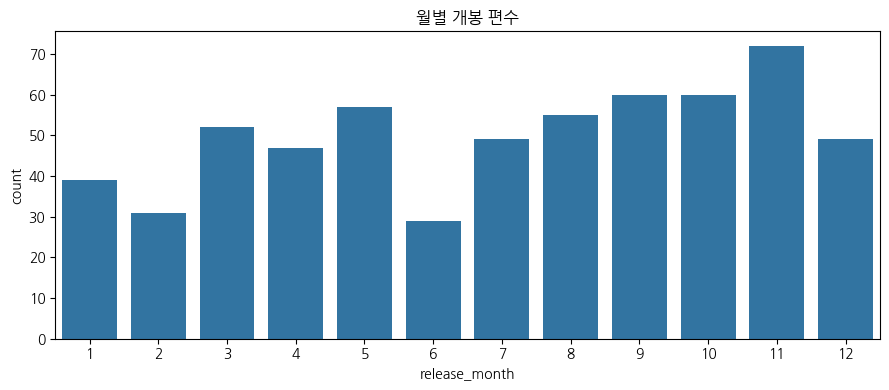

In [4]:
plt.figure(figsize=(9, 4))
sns.countplot(x='release_month', data=train)
plt.title('월별 개봉 편수')
plt.tight_layout()
plt.show()

#1단계 계절별 관객수

In [5]:
from scipy.stats import kruskal

season_stat = train.groupby('season')['box_off_num'].agg(n_films='size', box_median='median').loc[season_order]
print(season_stat)
print(kruskal(*[train[train['season'] == s]['box_off_num'] for s in season_order]).pvalue)

        n_films  box_median
season                     
봄           156      5942.5
여름          133     13886.0
가을          192     18618.5
겨울          119     27083.0
0.027898009642328647


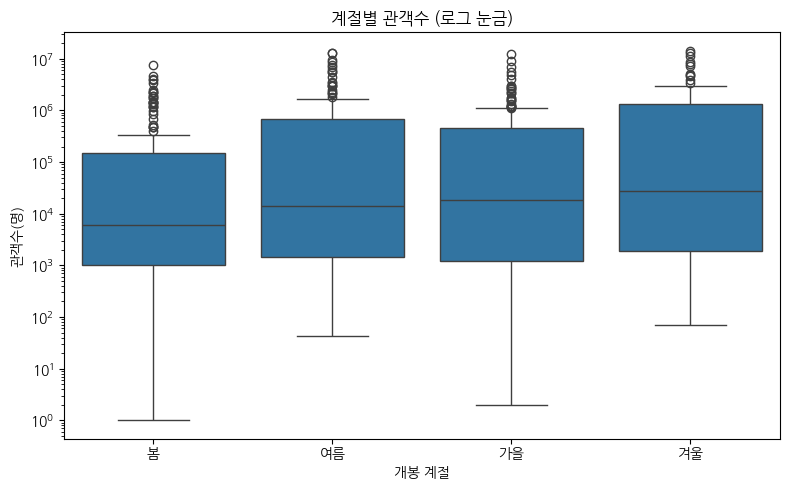

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='season', y='box_off_num', data=train, order=season_order)
plt.yscale('log')
plt.title('계절별 관객수 (로그 눈금)')
plt.xlabel('개봉 계절')
plt.ylabel('관객수(명)')
plt.tight_layout()
plt.show()

#2단계 겨울의 높은 관객수의 출처

In [11]:
from scipy.stats import mannwhitneyu

month_stat = train.groupby('release_month')['box_off_num'].agg(n_films='size', box_median='median')
print(month_stat)



               n_films  box_median
release_month                     
1                   39    283449.0
2                   31     10203.0
3                   52      4110.5
4                   47      7956.0
5                   57      7448.0
6                   29     18343.0
7                   49      9301.0
8                   55     16248.0
9                   60     14931.0
10                  60     45112.0
11                  72     15813.0
12                  49      9323.0


In [13]:
jan = train[train['release_month'] == 1]['box_off_num']
not_jan = train[train['release_month'] != 1]['box_off_num']
dec_feb = train[train['release_month'].isin([12, 2])]['box_off_num']
non_winter = train[train['season'] != '겨울']['box_off_num']

compare = pd.DataFrame({
    '집단 A': ['1월', '12·2월'],
    '집단 B': ['1월이 아닌 모든 달', '겨울이 아닌 달'],
    'A 편수': [len(jan), len(dec_feb)],
    'A 중앙값': [jan.median(), dec_feb.median()],
    'B 편수': [len(not_jan), len(non_winter)],
    'B 중앙값': [not_jan.median(), non_winter.median()],
    'p값': [mannwhitneyu(jan, not_jan).pvalue, mannwhitneyu(dec_feb, non_winter).pvalue]})
print(compare.round(3).to_string(index=False))

 집단 A        집단 B  A 편수    A 중앙값  B 편수   B 중앙값    p값
   1월 1월이 아닌 모든 달    39 283449.0   561 11650.0 0.027
12·2월    겨울이 아닌 달    80   9763.0   481 11666.0 0.187


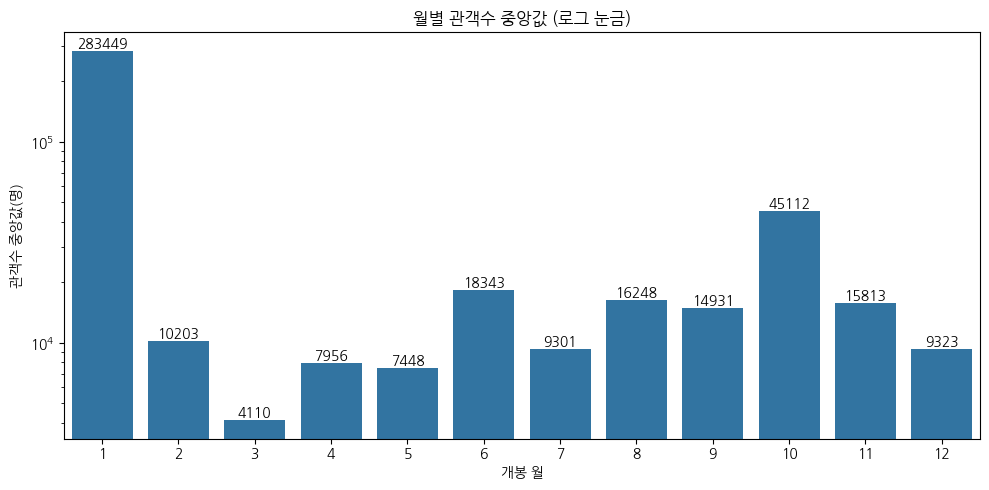

In [8]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=month_stat.index, y=month_stat['box_median'])
plt.yscale('log')
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.title('월별 관객수 중앙값 (로그 눈금)')
plt.xlabel('개봉 월')
plt.ylabel('관객수 중앙값(명)')
plt.tight_layout()
plt.show()

#3단계 1월 효과는 매년 반복되는가

In [14]:
train['release_year'] = train['release_time'].dt.year
train['is_jan'] = train['release_month'] == 1

year_stat = train.groupby(['release_year', 'is_jan'])['box_off_num'].agg(['size', 'median']).unstack()
year_stat.columns = ['n_other', 'n_jan', 'median_other', 'median_jan']
year_stat['ratio'] = year_stat['median_jan'] / year_stat['median_other']
print(year_stat.round(1))

month_median = train.groupby(['release_year', 'release_month'])['box_off_num'].median().unstack()
print(month_median.rank(axis=1, ascending=False)[1].astype(int))

              n_other  n_jan  median_other  median_jan  ratio
release_year                                                 
2010               82      8       26448.5     85270.5    3.2
2011               76      4       17117.5   1371404.5   80.1
2012               83      5       13429.0    467697.0   34.8
2013               91      4       14188.0   3583886.0  252.6
2014              118      9        7584.5    479280.0   63.2
2015              111      9        6226.0    151550.0   24.3
release_year
2010    5
2011    1
2012    2
2013    1
2014    1
2015    1
Name: 1, dtype: int64


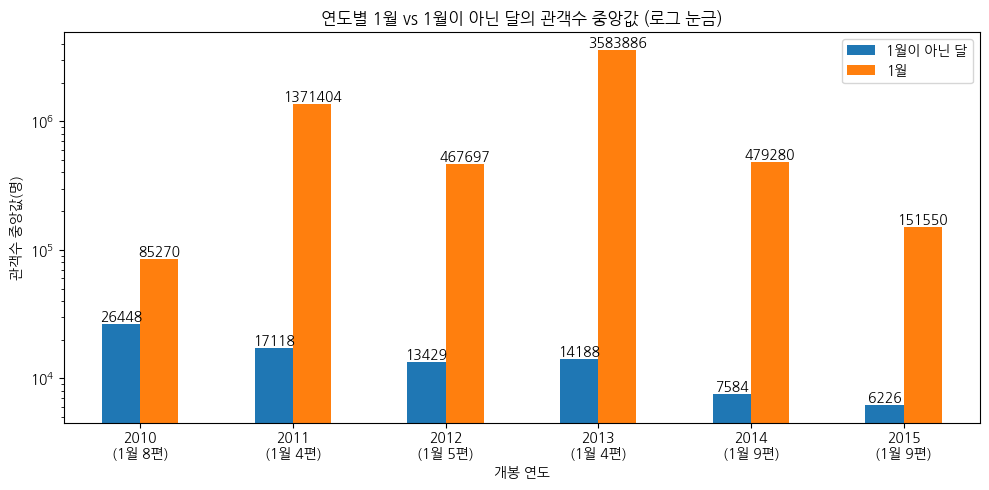

In [15]:
plot_data = year_stat[['median_other', 'median_jan']]
plot_data.columns = ['1월이 아닌 달', '1월']
plot_data.index = [f'{year}\n(1월 {n}편)' for year, n in zip(year_stat.index, year_stat['n_jan'])]

ax = plot_data.plot(kind='bar', figsize=(10, 5), rot=0)
plt.yscale('log')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f')
plt.title('연도별 1월 vs 1월이 아닌 달의 관객수 중앙값 (로그 눈금)')
plt.xlabel('개봉 연도')
plt.ylabel('관객수 중앙값(명)')
plt.tight_layout()
plt.show()

4단계

genre    드라마  다큐멘터리  멜로/로맨스   코미디    공포   액션  느와르
season                                           
봄       39.1   17.3    16.7   7.1   3.8  1.9  5.1
여름      27.1   14.3     7.5   7.5  15.0  8.3  4.5
가을      38.5   14.1    15.1   8.9   6.2  5.7  2.6
겨울      42.0   16.8    10.9  12.6   3.4  2.5  6.7
0.0010951851175651124


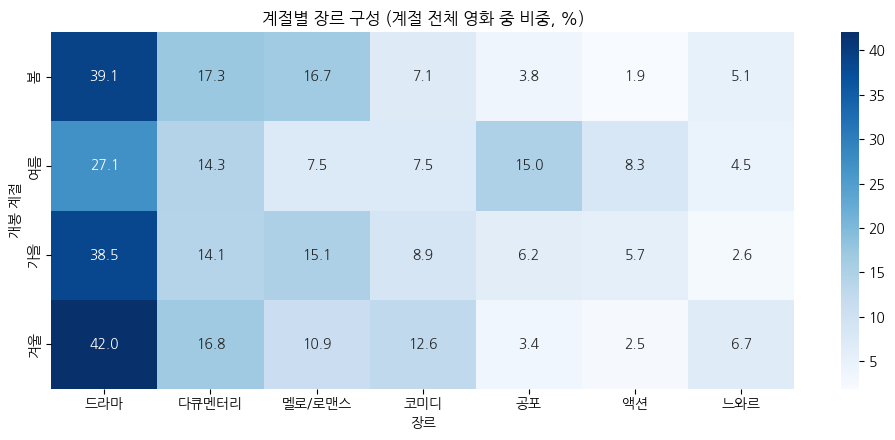

In [16]:
from scipy.stats import chi2_contingency, fisher_exact

genres = ['드라마', '다큐멘터리', '멜로/로맨스', '코미디', '공포', '액션', '느와르']
mix = pd.crosstab(train['season'], train['genre'], normalize='index').loc[season_order, genres] * 100
print(mix.round(1))

sub = train[train['genre'].isin(genres)]
print(chi2_contingency(pd.crosstab(sub['season'], sub['genre']))[1])

plt.figure(figsize=(10, 4.5))
sns.heatmap(mix, annot=True, fmt='.1f', cmap='Blues')
plt.title('계절별 장르 구성 (계절 전체 영화 중 비중, %)')
plt.xlabel('장르')
plt.ylabel('개봉 계절')
plt.tight_layout()
plt.show()

In [17]:
summer_horror = pd.crosstab(train['season'] == '여름', train['genre'] == '공포')
print(summer_horror)
print(fisher_exact(summer_horror)[1])

genre   False  True 
season              
False     445     22
True      113     20
0.00015114101336856982


In [18]:
horror = train[train['genre'] == '공포']
horror_stat = horror.groupby('season')['box_off_num'].agg(n_films='size', box_median='median').loc[season_order]
print(horror_stat)

        n_films  box_median
season                     
봄             6    389049.0
여름           20    125795.0
가을           12    528844.5
겨울            4      1570.0


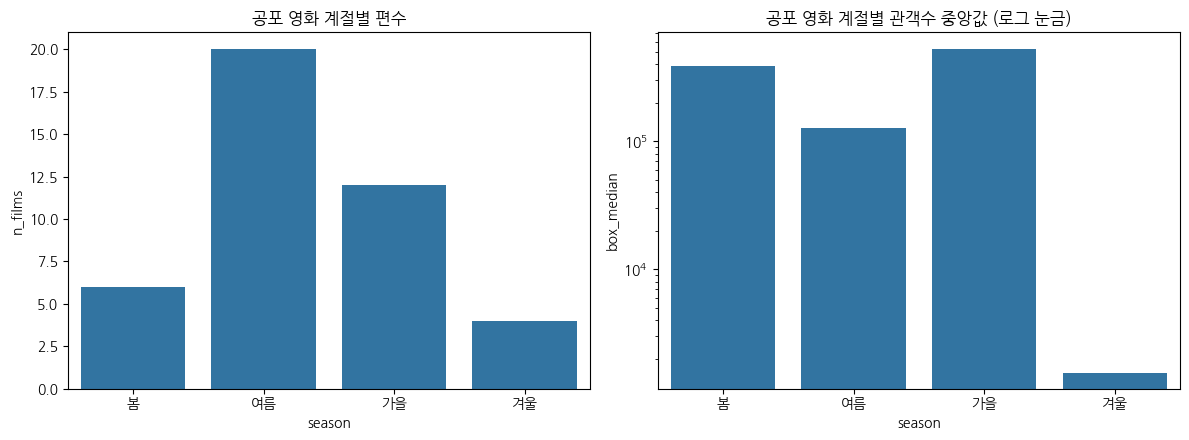

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=horror_stat.index, y=horror_stat['n_films'], ax=ax[0])
ax[0].set_title('공포 영화 계절별 편수')
sns.barplot(x=horror_stat.index, y=horror_stat['box_median'], ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('공포 영화 계절별 관객수 중앙값 (로그 눈금)')
plt.tight_layout()
plt.show()